# EDA

In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score , accuracy_score , roc_auc_score

In [2]:
# Data Load

df_train = pd.read_csv(r"../dataset/fashion-mnist_train.csv")
df_test = pd.read_csv(r"../dataset/fashion-mnist_test.csv")

X_train = df_train.drop(["label"] , axis = 1)
y_train = df_train["label"]

X_test = df_test.drop(["label"] , axis = 1)
y_test = df_test["label"]

df_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# NULL VALUES

null = df_train.isnull().sum()

null[null != 0]

Series([], dtype: int64)

#  NO NULL VAlUES FOUNDED

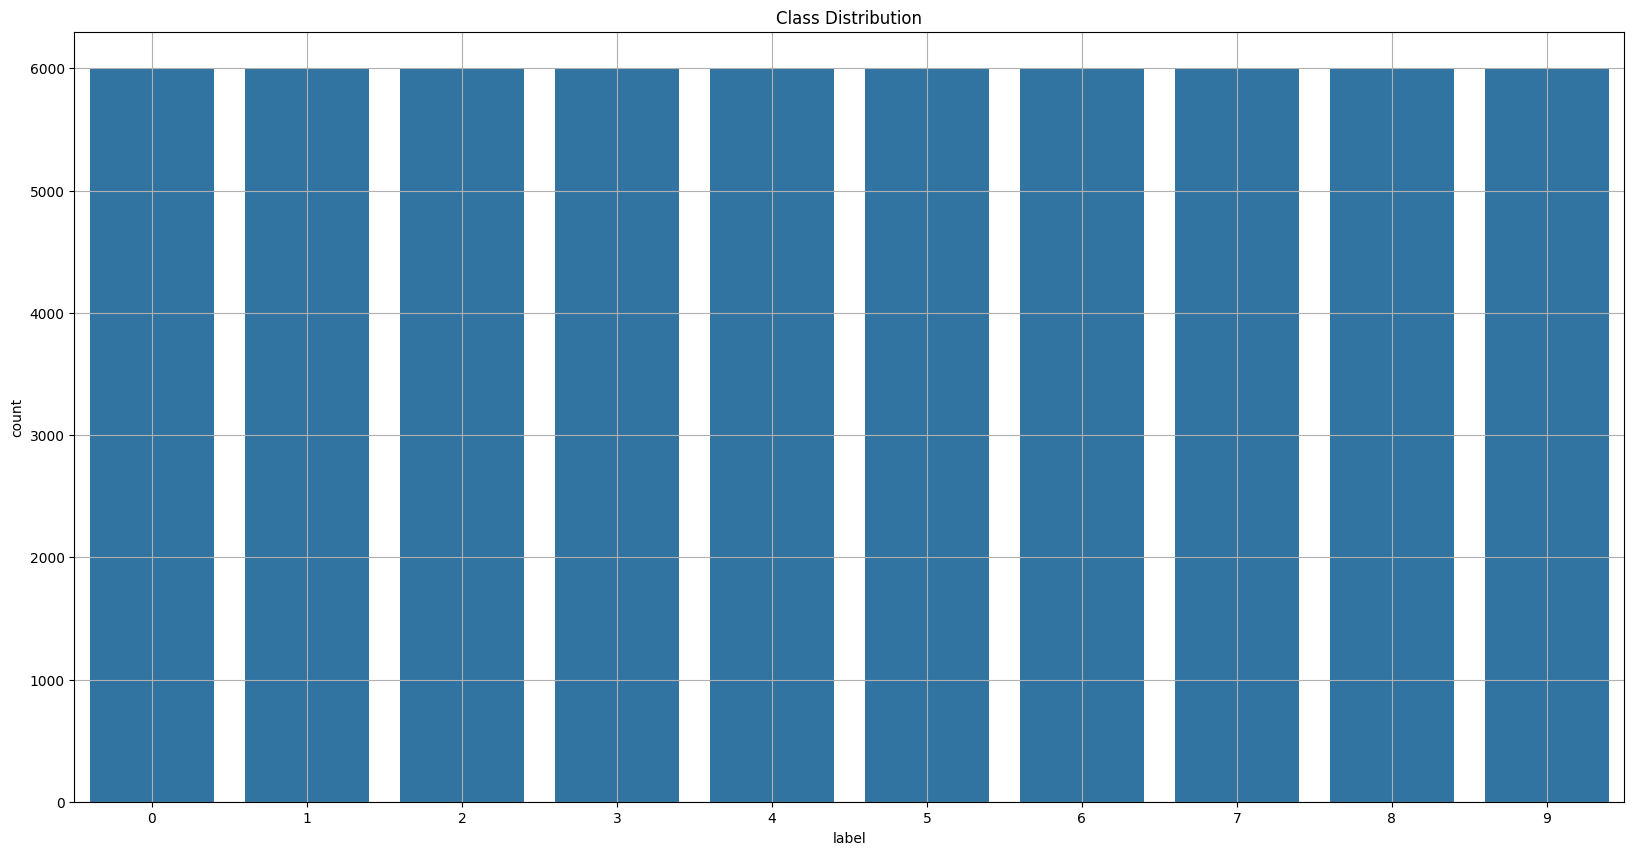

In [4]:
# Label Distribution

plt.figure(figsize = (20,10))
sns.countplot(
    x = "label" ,
    data  = df_train
)
plt.grid()
plt.title("Class Distribution")
plt.show()

# THE WHOLE DATASET IS EQUALLY BALANCED

# ALL IMAGES 

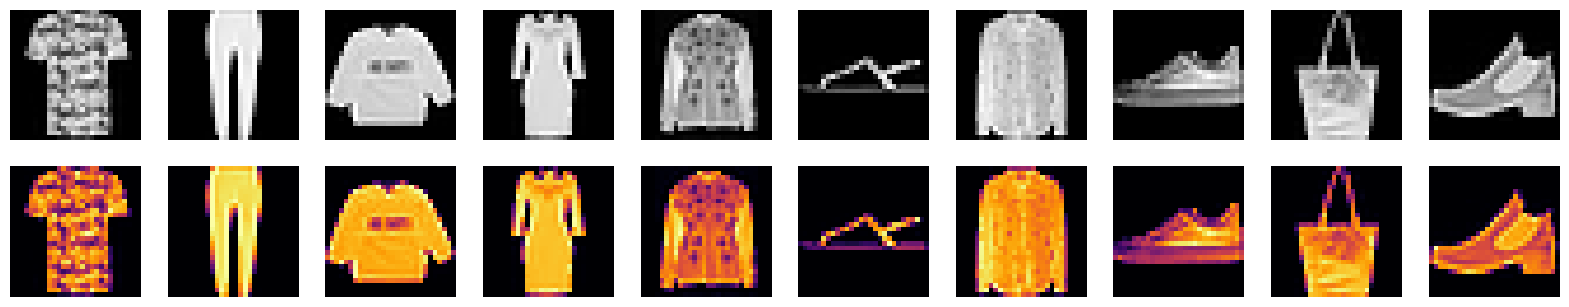

In [5]:
# Images Pics

n = [3 , 29 , 0 , 4 , 5 , 7 , 2 , 21 , 9 , 1 ]
a = 1 
b = 11

plt.figure(figsize = (20,20))

for i in n :
    
    plt.subplot(10 , 10 , a)
    a += 1
    img = X_train.iloc[i].values.reshape(28, 28)
    plt.imshow(img , cmap= "gray")
    plt.axis('off')

    plt.subplot(10 , 10 , b)
    b += 1
    img = X_train.iloc[i].values.reshape(28, 28)
    plt.imshow(img , cmap= "inferno")
    plt.axis('off')

    
plt.show()

In [6]:
# Base Model

pipeline = Pipeline([
    ("normalize" , MinMaxScaler()) ,
    ("xgbc" , XGBClassifier(
        n_jobs = -1 ,
        subsample = 0.8 ,
        colsample_bytree = 0.8 ,
        random_state = 42
    ))
])

pipeline.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('normalize', ...), ('xgbc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [7]:
# Scores

y_pred = pipeline.predict(X_test)

print(f"F1 SCORE : {f1_score(y_test , y_pred , average = "macro")}")
print(f"ACCURACY : {accuracy_score(y_test , y_pred)}")

F1 SCORE : 0.90778156926359
ACCURACY : 0.9081


In [8]:
# Feature Importance

imp = pipeline.named_steps["xgbc"].feature_importances_

imp = pd.Series(
    imp , 
    index = X_train.columns
).sort_values(ascending = False)

imp

pixel338    0.051410
pixel472    0.044049
pixel145    0.042107
pixel519    0.023098
pixel347    0.022942
              ...   
pixel1      0.000000
pixel112    0.000000
pixel142    0.000000
pixel31     0.000000
pixel28     0.000000
Length: 784, dtype: float32

# SOME FEATURES ARE NOT EVEN CONTRIBUTING 

In [14]:
# Feature with zero importance

imp[imp == 0]

pixel2      0.0
pixel784    0.0
pixel1      0.0
pixel112    0.0
pixel142    0.0
pixel31     0.0
pixel28     0.0
dtype: float32